In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


## 1. Load Dataset & Exploratory Data Analysis (EDA)

In [2]:
# Load dataset
df = pd.read_csv('train_test_network.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of dataset:")
print(df.head())


Dataset Shape: (211043, 44)

First 5 rows of dataset:
          src_ip  src_port         dst_ip  ...  weird_notice label      type
0   192.168.1.37      4444  192.168.1.193  ...             -     1  backdoor
1  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor
2  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor
3  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor
4  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor

[5 rows x 44 columns]


In [3]:
# Summary statistics and missing values check
print("Missing values in dataset:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found!")
print("\nTarget Class Distribution (0 = Normal, 1 = Attack):")
print(df['label'].value_counts())
print("\nAttack Types Distribution:")
print(df['type'].value_counts())
print("\nDataset Summary Statistics:")
print(df.describe())


Missing values in dataset:
No missing values found!

Target Class Distribution (0 = Normal, 1 = Attack):
label
1    161043
0     50000
Name: count, dtype: int64

Attack Types Distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

Dataset Summary Statistics:
            src_port       dst_port  ...  http_status_code          label
count  211043.000000  211043.000000  ...     211043.000000  211043.000000
mean    38646.519543    3495.153770  ...          0.303905       0.763081
std     19307.271048   10191.624778  ...          8.270377       0.425193
min         1.000000       0.000000  ...          0.000000       0.000000
25%     34608.000000      65.000000  ...          0.000000       1.000000
50%     44754.000000      80.000000  ...          0.000000       1.000000
75%     51133.000000    1253.0000

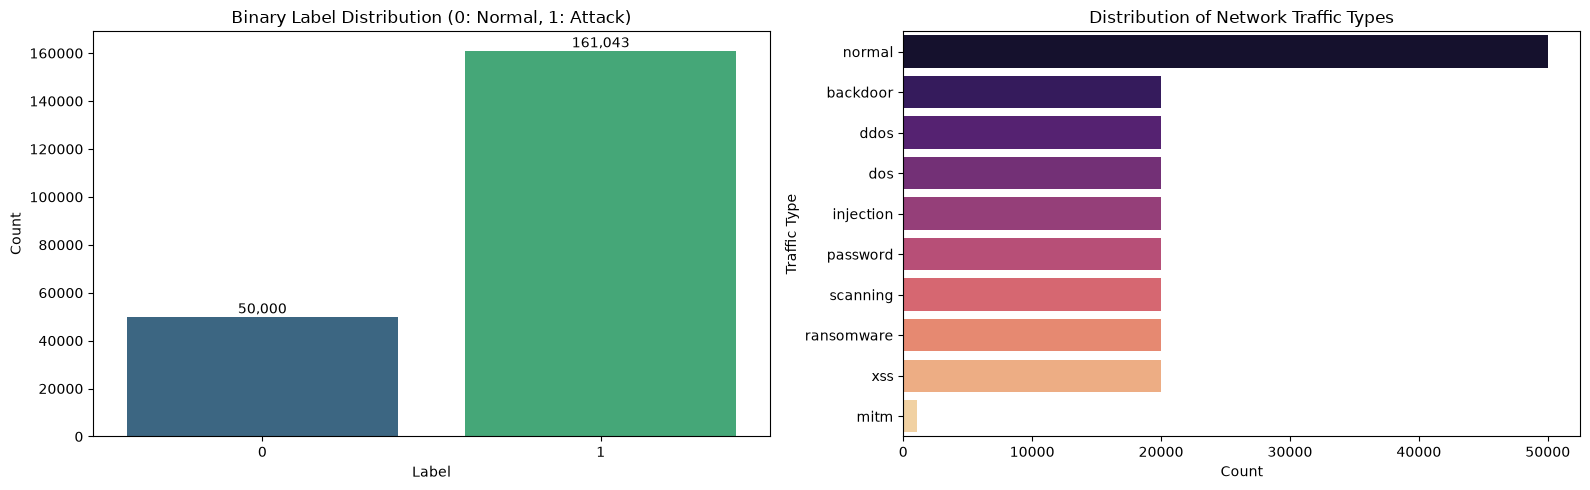

In [4]:
# Data Visualization - Target Distribution & Attack Types
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Binary Label Distribution
sns.countplot(x='label', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Binary Label Distribution (0: Normal, 1: Attack)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Attack Types Distribution
sns.countplot(y='type', data=df, ax=axes[1], palette='magma', order=df['type'].value_counts().index)
axes[1].set_title('Distribution of Network Traffic Types')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Traffic Type')

plt.tight_layout()
plt.show()


## 2. Feature Preprocessing & Scaling

In [5]:
# Separate features and target
# Target is 'label' (0 or 1); 'type' is dropped as it represents attack category names
X = df.drop(columns=['label', 'type'])
y = df['label'].values

# Encode categorical object columns using LabelEncoder
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Encoding {len(categorical_cols)} categorical features...")
X_encoded = X.copy()
for col in categorical_cols:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")


Encoding 26 categorical features...
X_train shape: (168834, 42), y_train shape: (168834,)
X_test shape: (42209, 42), y_test shape: (42209,)


## 3. Building the ANN Model Architecture

In [6]:
def build_ann_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_ann_model(X_train_scaled.shape[1])
model.summary()


Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)          

## 4. Model Training

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train_scaled, 
    y_train,
    validation_split=0.15,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20

  1/561 ━━━━━━━━━━━━━━━━━━━━ 40:55 4s/step - accuracy: 0.5195 - loss: 0.8313
  6/561 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5694 - loss: 0.7704 
 13/561 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6348 - loss: 0.6834 
 21/561 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6830 - loss: 0.6181
 29/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7180 - loss: 0.5705
 37/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7453 - loss: 0.5324
 45/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7671 - loss: 0.5010
 53/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7849 - loss: 0.4744
 62/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8014 - loss: 0.4487
 70/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8137 - loss: 0.4289
 78/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8243 - loss: 0.4111
 86/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8336 - loss: 0.3951
 94/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8417 - loss: 0.3808
102/561 

## 5. Model Evaluation & Accuracy Metrics

In [8]:
# Predict probabilities on test set
y_pred_prob = model.predict(X_test_scaled).flatten()

# Binary classification threshold at 0.5
y_pred = (y_pred_prob >= 0.5).astype(int)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print('=' * 50)
print('  ANN Binary Classification Performance Evaluation')
print('=' * 50)
print(f'  Accuracy Score                         : {accuracy:.4f} ({accuracy * 100:.2f}%)')
print(f'  Precision                              : {precision:.4f}')
print(f'  Recall                                 : {recall:.4f}')
print(f'  F1 Score                               : {f1:.4f}')
print(f'  ROC-AUC Score                          : {roc_auc:.4f}')
print('=' * 50)

if accuracy > 0.90:
    print('\n[SUCCESS] Target Accuracy (>90%) achieved!')
else:
    print('\n[WARNING] Accuracy below 90% threshold.')

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)']))



   1/1320 ━━━━━━━━━━━━━━━━━━━━ 3:16 149ms/step
  34/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step    
  58/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
  84/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 113/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 140/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 165/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 190/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 218/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 243/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 267/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 292/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 317/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 345/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 369/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 393/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 416/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 441/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 467/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 496/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 523/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 551/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 579/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 6

## 6. Visualization & Error Analysis

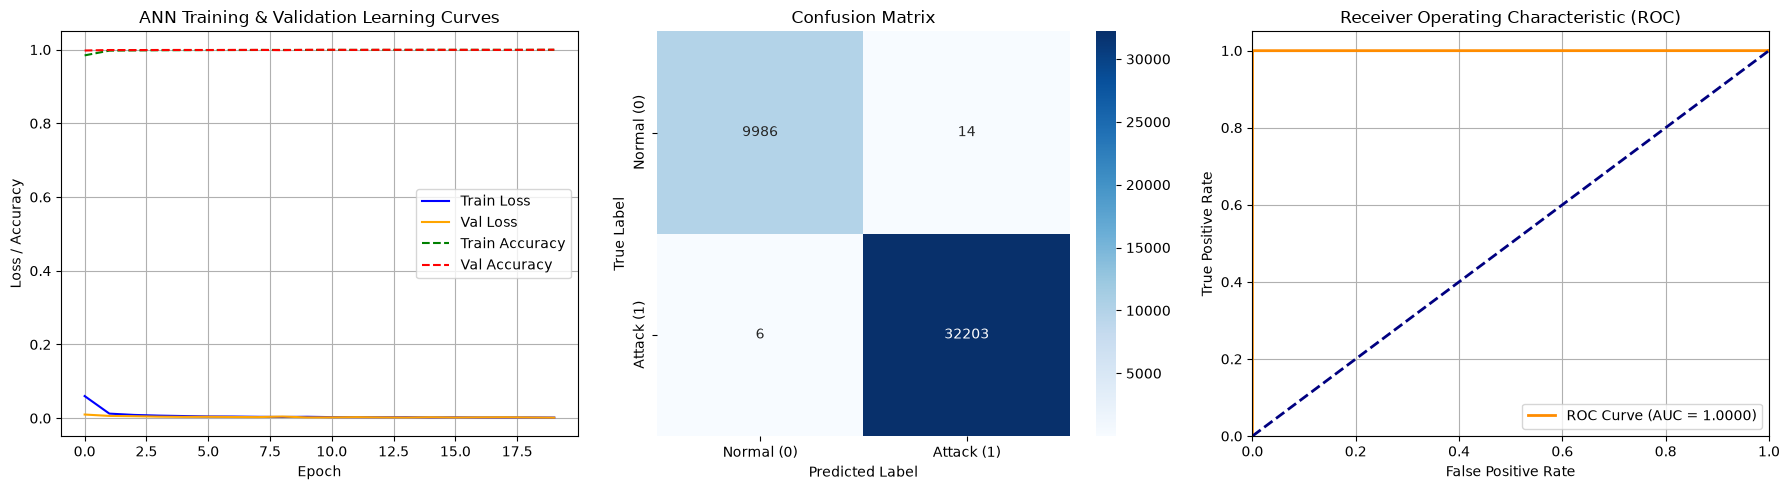

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training & Validation Loss and Accuracy
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linestyle='--', color='green')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linestyle='--', color='red')
axes[0].set_title('ANN Training & Validation Learning Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss / Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Plot 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Receiver Operating Characteristic (ROC)')
axes[2].legend(loc="lower right")
axes[2].grid(True)

plt.tight_layout()
plt.show()
